<a href="https://colab.research.google.com/github/orineo1/GlobalConditional/blob/master/mnistExpThesisFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from torchvision.datasets import EMNIST

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.datasets import EMNIST
import numpy as np
from tqdm.notebook import tqdm


In [ ]:
# Imports

# Pytorch
import torch
import torchvision

# HuggingFace
import datasets
import diffusers
import accelerate

# Training and Visualization
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os
import PIL

import torch
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF
import numpy as np
import random
from tqdm import tqdm


import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict



In [ ]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
import torch
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt
import numpy as np
import string

def get_char(idx):
    if idx < 10: return str(idx)
    elif idx < 36: return string.ascii_uppercase[idx-10]
    else: return string.ascii_lowercase[idx-36]



def analyze_single_label(model, combined_loader, target_label=None, samples_per_label=1000):
    if target_label is not None:
        # Single label analysis
        print(f"Collecting {samples_per_label} samples for label {target_label} ('{get_char(target_label)}')")
        target_labels = [target_label]
    else:
        # All labels analysis
        print(f"Analyzing all labels with {samples_per_label} samples each")
        target_labels = list(range(62))  # All EMNIST byclass labels (0-61)

    # Collect samples for all target labels
    label_samples = {label: [] for label in target_labels}
    label_counts = {label: 0 for label in target_labels}

    for batch_data in combined_loader:
        imgs, labels, angles = batch_data

        for i in range(len(imgs)):
            label = labels[i].item()
            if label in target_labels and label_counts[label] < samples_per_label:
                label_samples[label].append((imgs[i], angles[i].item()))
                label_counts[label] += 1

        # Check if we have enough samples for all labels
        if all(count >= samples_per_label for count in label_counts.values()):
            break

    # Filter out labels with insufficient samples
    valid_labels = [label for label in target_labels if label_counts[label] > 0]
    print(f"Collected samples for {len(valid_labels)} labels")

    # Process each label and collect results by category
    digits_data = {}
    upper_data = {}
    lower_data = {}

    for label in valid_labels:
        samples = label_samples[label]
        if len(samples) == 0:
            continue

        print(f"Processing label {label} ('{get_char(label)}') - {len(samples)} samples")

        all_corrected_angles = []

        for i, (img, true_angle) in enumerate(samples):
            condition_tensor = img.flatten().unsqueeze(0)

            with torch.no_grad():
                angles = circular_to_angles(model.sample(nsamples=250, condition_x=condition_tensor,
                                                       ts=[150.0, 50.0, 20.0, 10.0, 5.0, 1.])[0])
                corrected = (angles.detach().cpu().numpy() - true_angle) % 360
                all_corrected_angles.append(corrected)

        # Combine angles
        all_corrected = []
        for arr in all_corrected_angles:
            all_corrected.extend(arr.flatten())
        all_corrected = np.array(all_corrected)

        mean_angle = np.mean(all_corrected)

        # Categorize by label range
        if label < 10:  # Digits 0-9
            digits_data[label] = (all_corrected, mean_angle)
        elif label < 36:  # Uppercase A-Z
            upper_data[label] = (all_corrected, mean_angle)
        else:  # Lowercase a-z
            lower_data[label] = (all_corrected, mean_angle)

    # Plot digits (0-9)
    if digits_data:
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        axes = axes.flatten()
        fig.suptitle('Digits (0-9)', fontsize=16)

        for i, (label, (angles, mean_angle)) in enumerate(sorted(digits_data.items())):
            axes[i].hist(angles, bins=30, alpha=0.7, density=True,
                        color='lightblue', edgecolor='black', range=(0, 360))
            axes[i].axvline(mean_angle, color='red', linestyle='--', linewidth=2)
            axes[i].set_title(f'"{get_char(label)}" (Mean: {mean_angle:.1f}°)')
            axes[i].set_xlim(0, 360)
            axes[i].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Plot uppercase letters (A-Z)
    if upper_data:
        n_upper = len(upper_data)
        n_cols = 6
        n_rows = (n_upper + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3*n_rows))
        if n_rows == 1:
            axes = [axes] if n_cols == 1 else axes
        else:
            axes = axes.flatten()
        fig.suptitle('Uppercase Letters (A-Z)', fontsize=16)

        for i, (label, (angles, mean_angle)) in enumerate(sorted(upper_data.items())):
            axes[i].hist(angles, bins=30, alpha=0.7, density=True,
                        color='lightgreen', edgecolor='black', range=(0, 360))
            axes[i].axvline(mean_angle, color='red', linestyle='--', linewidth=2)
            axes[i].set_title(f'"{get_char(label)}" (Mean: {mean_angle:.1f}°)')
            axes[i].set_xlim(0, 360)
            axes[i].grid(True, alpha=0.3)

        # Hide unused subplots
        for i in range(len(upper_data), len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        plt.show()

    # Plot lowercase letters (a-z)
    if lower_data:
        n_lower = len(lower_data)
        n_cols = 6
        n_rows = (n_lower + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3*n_rows))
        if n_rows == 1:
            axes = [axes] if n_cols == 1 else axes
        else:
            axes = axes.flatten()
        fig.suptitle('Lowercase Letters (a-z)', fontsize=16)

        for i, (label, (angles, mean_angle)) in enumerate(sorted(lower_data.items())):
            axes[i].hist(angles, bins=30, alpha=0.7, density=True,
                        color='lightcoral', edgecolor='black', range=(0, 360))
            axes[i].axvline(mean_angle, color='red', linestyle='--', linewidth=2)
            axes[i].set_title(f'"{get_char(label)}" (Mean: {mean_angle:.1f}°)')
            axes[i].set_xlim(0, 360)
            axes[i].grid(True, alpha=0.3)

        # Hide unused subplots
        for i in range(len(lower_data), len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        plt.show()

    print("Analysis complete!")
    return digits_data, upper_data, lower_data

# Usage:
# combined_loader = DataLoader(RotatedEMNIST(), batch_size=512, shuffle=True, num_workers=2)
# For single label: analyze_single_label(model, combined_loader, target_label=8)
# For all labels:

## Sample Angle by image - OLD VERSION

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from typing import List

# Assuming you have these from NN_utils
# from NN_utils import GenericNN, TimeEmbedding

# Simple implementations if NN_utils is not available
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return emb

class GenericNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU()
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t_emb=None):
        if t_emb is not None:
            # Ensure t_emb has the right shape for broadcasting
            if t_emb.dim() == 2 and x.dim() == 2:
                x = x + t_emb
        return self.net(x)

# Utility functions for circular angle conversion
def angles_to_circular(angles_deg):
    """Convert angles in degrees to circular representation (cos, sin)"""
    angles_rad = torch.deg2rad(angles_deg)
    return torch.stack([torch.cos(angles_rad), torch.sin(angles_rad)], dim=-1)

def circular_to_angles(circular):
    """Convert circular representation back to angles in degrees"""
    angles_rad = torch.atan2(circular[..., 1], circular[..., 0])
    return torch.rad2deg(angles_rad) % 360


# Consistency model helper functions
def kerras_boundaries(sigma_min, sigma_max, N, rho):
    steps = torch.arange(N + 1, dtype=torch.float32, device='cuda' if torch.cuda.is_available() else 'cpu')
    return (sigma_max ** (-1 / rho) + steps / N * (sigma_min ** (-1 / rho) - sigma_max ** (-1 / rho))) ** (-rho)

def smooth_huber_loss(x, y, c=0.00054):
    """iCT's smooth Huber loss: d(x, y) = √(||x - y||₂² + c²) - c"""
    l2_squared = torch.sum((x - y) ** 2, dim=-1, keepdim=True)
    return torch.sqrt(l2_squared + c**2) - c

def ict_discretization_schedule(epoch, total_epochs, s0=10, s1=1280):
    """iCT improved discretization curriculum: N(k) = min(s₀ * 2^⌊k/K'⌋, s₁) + 1"""
    K_prime = math.floor(math.log2(s1 / s0))
    if K_prime <= 0:
        return s0 + 1

    progress_ratio = epoch / total_epochs
    exponent = math.floor(progress_ratio * K_prime)
    N = min(s0 * (2 ** exponent), s1) + 1
    return int(N)

class RandomGaussianBlur(nn.Module):
    def __init__(self, kernel_size=5, sigma_range=(0.5, 2.0)):
        super().__init__()
        self.kernel_size = kernel_size
        self.sigma_range = sigma_range

    def forward(self, x):
        sigma = torch.empty(1).uniform_(*self.sigma_range).item()
        coords = torch.arange(self.kernel_size) - self.kernel_size // 2
        g = torch.exp(-(coords**2) / (2*sigma**2))
        g = g / g.sum()
        kernel = (g[:, None] * g[None, :]).to(x.device)
        kernel = kernel[None, None, :, :]
        return F.conv2d(x, kernel, padding=self.kernel_size//2)
class ConditionAugmentation:
    """
    Apply augmentation to condition images during training
    Use this in your training loop!
    """
    def __init__(self, noise_level=0.05, dropout_prob=0.1):
        self.noise_level = noise_level
        self.dropout_prob = dropout_prob

    def __call__(self, condition_imgs):
        """
        condition_imgs: [B, 784] flattened MNIST images
        """
        if not torch.is_grad_enabled():  # Skip during eval
            return condition_imgs

        imgs = condition_imgs.clone()

        # Add Gaussian noise
        if self.noise_level > 0:
            noise = torch.randn_like(imgs) * self.noise_level
            imgs = imgs + noise

        # Random pixel dropout
        if self.dropout_prob > 0:
            mask = torch.bernoulli(torch.ones_like(imgs) * (1 - self.dropout_prob))
            imgs = imgs * mask

        return imgs

########## changes
class ImprovedCondEmbed_v3(nn.Module):
    """
    Modern design with:
    - Residual connections (better gradient flow)
    - Stochastic Depth (implicit ensemble)
    - Weight standardization via GroupNorm
    - Progressive dropout
    """
    def __init__(self, nunits, drop_path_rate=0.1):
        super().__init__()
        self.nunits = nunits

        self.input_proj = nn.Conv2d(1, 64, 1)  # 1x1 projection

        # Residual Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Dropout2d(0.1),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
        )
        self.act1 = nn.SiLU()
        self.pool1 = nn.MaxPool2d(2)  # 14x14

        # Transition
        self.transition = nn.Conv2d(64, 128, 1)

        # Residual Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
            nn.Dropout2d(0.15),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
        )
        self.act2 = nn.SiLU()
        self.pool2 = nn.MaxPool2d(2)  # 7x7

        # Output projection
        self.output_proj = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global pooling instead of flatten
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, self.nunits),
            nn.SiLU(),
        )

        self.drop_path_rate = drop_path_rate

    def forward(self, x):
        # Unflatten input
        x = x.view(-1, 1, 28, 28)

        # Initial projection
        x = self.input_proj(x)

        # Block 1 with residual
        identity = x
        out = self.block1(x)
        if self.training and self.drop_path_rate > 0:
            # Stochastic depth
            if torch.rand(1).item() > self.drop_path_rate:
                out = out + identity
        else:
            out = out + identity
        x = self.act1(out)
        x = self.pool1(x)

        # Transition
        x = self.transition(x)

        # Block 2 with residual
        identity = x
        out = self.block2(x)
        if self.training and self.drop_path_rate > 0:
            if torch.rand(1).item() > self.drop_path_rate:
                out = out + identity
        else:
            out = out + identity
        x = self.act2(out)
        x = self.pool2(x)

        # Output
        x = self.output_proj(x)
        return x
import torch.nn.functional as F
class CondEmbedMoGVAE(nn.Module):
    def __init__(self, nunits=128, latent_dim=64, num_components=5):
        super().__init__()
        self.num_components = num_components
        self.latent_dim = latent_dim

        # CNN encoder (no Unflatten here!)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # -> 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # -> 7x7
            nn.ReLU(),
            nn.Flatten(),
        )

        in_features = 64 * 7 * 7

        # Separate heads for each MoG parameter
        self.fc_mu = nn.Linear(in_features, num_components * latent_dim)
        self.fc_logvar = nn.Linear(in_features, num_components * latent_dim)
        self.fc_pi = nn.Linear(in_features, num_components)  # mixture weights

        # Output projection
        self.fc_out = nn.Linear(latent_dim, nunits)

    def forward(self, x, sample=True):
        """
        Args:
            x: conditioning image (B, 784) or (B, 1, 28, 28)
            sample: whether to sample from the mixture or return means
        Returns:
            embedding: (B, nunits)
        """
        # Handle both flat and already-shaped images
        if x.dim() == 2:  # (B, 784)
            x = x.view(-1, 1, 28, 28)
        elif x.dim() == 3:  # (B, 28, 28)
            x = x.unsqueeze(1)

        h = self.encoder(x)

        mu = self.fc_mu(h).view(-1, self.num_components, self.latent_dim)
        logvar = self.fc_logvar(h).view(-1, self.num_components, self.latent_dim)
        pi_logits = self.fc_pi(h)
        pi = F.softmax(pi_logits, dim=-1)

        if sample:
            comp_idx = torch.multinomial(pi, 1).squeeze(1)
            selected_mu = mu[torch.arange(mu.size(0)), comp_idx]
            selected_logvar = logvar[torch.arange(logvar.size(0)), comp_idx]
            std = torch.exp(0.5 * selected_logvar)
            eps = torch.randn_like(std)
            z = selected_mu + eps * std
        else:
            z = (pi.unsqueeze(-1) * mu).sum(dim=1)

        return self.fc_out(z)


########## end of changes


# Circular Angle Consistency Model based on ConsistencyModelImprovedAlliCT
class CircularAngleConsistencyModel(nn.Module):
    def __init__(self, nfeatures: int = 2, img_features: int = 784, eps: float = 0.002,
                 nunits: int = 128, depth: int = 6, device=None):
        super().__init__()
        self.eps = eps
        self.nfeatures = nfeatures  # 2 for circular angles (cos, sin)
        self.img_features = img_features  # 784 for flattened MNIST
        self.nunits = nunits
        self.device = device if device is not None else torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.betas = None

        ########## changes
        # Replace simple CNN cond_embed with Mixture-of-Gaussians VAE encoder
        # self.cond_embed = CondEmbedMoGVAE(nunits=nunits, latent_dim=64, num_components=5)

        self.cond_embed = nn.Sequential(
            nn.Unflatten(1, (1, 28, 28)),

            # Block 1 - Reduced to 32 channels
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Dropout2d(0.1),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.MaxPool2d(2),  # 14x14

            # Block 2 - Reduced to 64 channels
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Dropout2d(0.15),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.MaxPool2d(2),  # 7x7
            nn.Dropout2d(0.2),

            # Flatten and project
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64 * 7 * 7, self.nunits),
            nn.SiLU(),
        )
#         ImprovedCondEmbed_v3(
#     nunits=self.nunits,
#     drop_path_rate=0.1
# )
        ########## end of changes

        self.input_layer = nn.Linear(nfeatures, nunits)

        # Layer Normalization
        self.input_norm = nn.LayerNorm(nunits)
        self.output_norm = nn.LayerNorm(nunits)

        self.time_embed = TimeEmbedding(nunits)
        self.out = nn.Linear(nunits, nfeatures)
        self.net = GenericNN(
            input_dim=nunits,
            hidden_dims=[nunits] * depth,
            output_dim=nunits,
        )

        # Calculate c parameter for smooth Huber loss based on data dimensionality
        self.c_huber = 0.00054 * math.sqrt(nfeatures)

        self.to(self.device)


    def ict_noise_sampling(self, boundaries, batch_size, P_mean=-1.1, P_std=2.0, device='cuda'):
        """iCT improved noise schedule sampling using error function distribution"""
        N = len(boundaries) - 1

        # Calculate probabilities for each timestep using erf
        log_sigmas = torch.log(boundaries[:-1])  # σᵢ
        log_sigmas_next = torch.log(boundaries[1:])  # σᵢ₊₁

        # Calculate erf terms
        sqrt_2_std = math.sqrt(2) * P_std
        erf_next = torch.erf((log_sigmas_next - P_mean) / sqrt_2_std)
        erf_curr = torch.erf((log_sigmas - P_mean) / sqrt_2_std)

        # p(i) ∝ erf((log(σᵢ₊₁) - P_mean)/√2P_std) - erf((log(σᵢ) - P_mean)/√2P_std)
        probs = erf_next - erf_curr
        probs = torch.clamp(probs, min=1e-8)  # Ensure positive probabilities
        probs = probs / probs.sum()  # Normalize

        # Sample timestep indices according to computed probabilities
        t_idx = torch.multinomial(probs, batch_size, replacement=True).unsqueeze(1).to(device)

        return t_idx

    def forward(self, x, t, cond=None):
        """
        x: circular angles [B, 2]
        t: timesteps [B, 1] or scalar
        cond: flattened images [B, 784]
        """
        x_ori = x
        x = self.input_layer(x)

        # Apply input normalization
        x = self.input_norm(x)

        # Add image conditioning
        if cond is not None:
            # Flatten image if needed
            if cond.dim() == 4:  # [B, 1, 28, 28]
                cond = cond.view(cond.size(0), -1)
            elif cond.dim() == 3:  # [B, 28, 28]
                cond = cond.view(cond.size(0), -1)

            cond_emb = self.cond_embed(cond)
            x = x + cond_emb

        # Ensure t is (B, 1) and get time embedding
        if isinstance(t, (float, int)):
            t = torch.tensor([t] * x.shape[0], dtype=torch.float32, device=x.device).unsqueeze(1)
        elif t.dim() == 1:
            t = t.unsqueeze(1)
        elif t.dim() == 3:  # Handle [B, 1, 1] case
            t = t.squeeze(-1)

        # Get time embedding - should be [B, nunits]
        time_emb = self.time_embed(t.squeeze(-1))  # Remove last dim for time embed

        # Pass through network with time embedding
        x = x + time_emb  # Add time embedding directly to x
        x = self.net(x)

        # Apply output normalization
        x = self.output_norm(x)

        x = self.out(x)

        # Output skip connection with consistency weights
        t_for_weights = t - self.eps
        c_skip_t = 0.25 / (t_for_weights.pow(2) + 0.25)
        c_out_t = 0.25 * t_for_weights / ((t_for_weights + self.eps).pow(2) + 0.25).sqrt()

        result = c_skip_t * x_ori + c_out_t * x

        # Normalize to unit circle for circular constraint
        result = result / (torch.norm(result, dim=1, keepdim=True) + 1e-8)

        return result

    def loss(self, x, z, t0, t1, ema_model, cond=None):
        """Consistency model loss with improved weighting and smooth Huber loss"""
        with torch.no_grad():
            x2 = x + z * t1
            x1 = x + z * t0
            x1 = ema_model(x1, t0, cond=cond)

        x2 = self(x2, t1, cond=cond)

        # Apply improved loss weighting: λ(t) = 1/(t1-t0)
        lambda_t = 1.0 / (t1 - t0 + 1e-8)

        # Use smooth Huber loss
        huber_loss = smooth_huber_loss(x1, x2, c=self.c_huber)
        weighted_loss = lambda_t * huber_loss

        return weighted_loss.mean()

    def sample(self, nsamples=250, condition_x=None,
               ts: List[float] = [150.0, 50.0, 20.0, 10.0, 5.0, 1.], device=None):
        """Sample circular angles using consistency model sampling"""
        device = self.device if device is None else device

        if condition_x is not None:
            condition_x = condition_x.to(device)
            # Flatten if needed
            if condition_x.dim() > 2:
                condition_x = condition_x.view(condition_x.size(0), -1)

        # Initialize with random circular angles
        x = torch.randn(nsamples, self.nfeatures, device=device) * ts[0]
        x = x / (torch.norm(x, dim=1, keepdim=True) + 1e-8)  # Normalize to unit circle
        x = x.to(device)

        for t in ts[1:]:
            z = torch.randn_like(x)
            x = x + math.sqrt(t ** 2 - self.eps ** 2) * z
            x = self(x, t, cond=condition_x)

        return x, None, None
    def train_model(self, dataloader, nepochs: int = 100, device: str = "cpu",
                    use_improved_training=True, save_dir="checkpoints",
                    checkpoint_path=None, start_epoch=None):
        """Train the circular angle consistency model"""
        import os

        os.makedirs(save_dir, exist_ok=True)

        self.to(device)
        aug = ConditionAugmentation(noise_level=0.05, dropout_prob=0.1)

        # optim = torch.optim.AdamW(self.parameters(), lr=1e-5)
        optim = torch.optim.AdamW(
          self.parameters(),
          lr=1e-4,
          weight_decay=1e-4
      )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=nepochs, eta_min=1e-7)

        # Improved Consistency Models: Use μ=0 (no EMA updates)
        if use_improved_training:
            ema_model = self
        else:
            ema_model = CircularAngleConsistencyModel(
                nfeatures=self.nfeatures,
                img_features=self.img_features,
                nunits=self.nunits
            )
            ema_model.to(device)
            ema_model.load_state_dict(self.state_dict())

        losses = []
        start_epoch_num = 1

        # Load checkpoint if provided
        if checkpoint_path and os.path.exists(checkpoint_path):
            print(f"Loading checkpoint from {checkpoint_path}")
            checkpoint = torch.load(checkpoint_path, map_location=device)

            # Load model state
            self.load_state_dict(checkpoint['model_state_dict'])

            # Load optimizer and scheduler states
            optim.load_state_dict(checkpoint['optimizer_state_dict'])
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

            # Load training info
            start_epoch_num = checkpoint['epoch'] + 1
            losses = checkpoint.get('losses_history', [])

            print(f"Resuming training from epoch {start_epoch_num}")
            print(f"Previous loss: {checkpoint['loss']:.6f}")

        # Override start epoch if specified
        if start_epoch is not None:
            start_epoch_num = start_epoch

        pbar = tqdm(range(start_epoch_num, nepochs + 1))

        for epoch in pbar:

            # iCT improved discretization curriculum
            N = ict_discretization_schedule(epoch, nepochs, s0=10, s1=1280)

            boundaries = kerras_boundaries(10.0, 0.002, N, 7.0).to(device)
            self.betas = boundaries
            loss_ema = None
            for batch_data in dataloader:#dataloader
                if len(batch_data) == 2:  # (images, angles)
                    images, angles = batch_data
                    labels = None
                    correlations = None
                elif len(batch_data) == 3:  # (images, labels, angles)
                    images, labels, angles = batch_data
                    correlations = None
                else:  # (images, labels, angles, correlations)
                    images, labels, angles, correlations = batch_data

                images = images.to(device)
                angles = angles.to(device)



                # Convert angles to circular representation
                x = angles_to_circular(angles)


            # for batch_data in dataloader:
            #     if len(batch_data) == 2:  # (images, angles)
            #         images, angles = batch_data
            #         labels = None
            #     else:  # (images, angles, labels)
            #         images, labels,angles = batch_data

            #     images = images.to(device)
            #     angles = angles.to(device)

            #     # Convert angles to circular representation
            #     x = angles_to_circular(angles)

                # Flatten images for conditioning
                cond_x = images.view(images.size(0), -1)
                cond_x = aug(cond_x)  # Augment condition images
                z = torch.randn_like(x)

                # iCT improved noise schedule sampling
                t_idx = self.ict_noise_sampling(boundaries, x.shape[0], P_mean=-1.1, P_std=2.0, device=device)
                t0 = boundaries[t_idx]
                t1 = boundaries[t_idx + 1]

                optim.zero_grad()

                # For improved training, use stop_gradient on the target
                if use_improved_training:
                    with torch.no_grad():
                        x2_target = x + z * t1
                        x1_target = x + z * t0
                        x1_target = ema_model(x1_target, t0, cond=cond_x)

                    x2_pred = self(x2_target, t1, cond=cond_x)

                    # Apply improved loss weighting and smooth Huber loss
                    lambda_t = 1.0 / (t1 - t0 + 1e-8)
                    huber_loss = smooth_huber_loss(x1_target, x2_pred, c=self.c_huber)
                    weighted_loss = lambda_t * huber_loss
                    loss = weighted_loss.mean()
                else:
                    loss = self.loss(x, z, t0, t1, ema_model=ema_model, cond=cond_x)

                loss.backward()
                optim.step()
                scheduler.step()

                losses.append(loss.item())

                if loss_ema is None:
                    loss_ema = loss.item()
                else:
                    loss_ema = 0.9 * loss_ema + 0.1 * loss.item()

                # Only update EMA if using original training
                if not use_improved_training:
                    with torch.no_grad():
                        mu = math.exp(2 * math.log(0.95) / N)
                        for p, ema_p in zip(self.parameters(), ema_model.parameters()):
                            ema_p.mul_(mu).add_(p, alpha=1 - mu)
                else:
                    mu = 0.0

            pbar.set_description(f"loss: {loss_ema:.6f}, mu: {mu:.4f}, N: {N}")

            # Generate samples and save checkpoint every 10 epochs
            if epoch % 25 == 0:
                print(f"\nEpoch {epoch}/{nepochs} completed")
                self.generate_sample_predictions(dataloader, device, epoch)
                analyze_single_label(self, combined_loader)
                # Save checkpoint
                checkpoint = {
                    'epoch': epoch,
                    'model_state_dict': self.state_dict(),
                    'optimizer_state_dict': optim.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'loss': loss_ema,
                    'losses_history': losses,
                    'nfeatures': self.nfeatures,
                    'img_features': self.img_features
                }

                checkpoint_path = os.path.join(save_dir, f'circular_ict_epoch_{epoch}.pt')
                torch.save(checkpoint, checkpoint_path)
                print(f"Checkpoint saved: {checkpoint_path}")

        return losses
    def generate_sample_predictions(self, dataloader, device, epoch, num_samples=10, samples_per_condition=250):
        """Generate images (top row) and histograms (bottom row) for conditional angle sampling"""
        print(f"\n--- Generating conditional angle histograms at epoch {epoch} ---")
        self.eval()

        # Get a batch of test images
        for batch_data in dataloader:
            if len(batch_data) == 2:
                images, true_angles = batch_data
            else:
                images, labels, true_angles = batch_data

            # Take only first num_samples
            images = images[:num_samples].to(device)
            true_angles = true_angles[:num_samples]
            break

        # Create 2x5 grid: images on top, histograms on bottom
        fig, axes = plt.subplots(2, 5, figsize=(25, 10))

        for i in range(5):  # 5 columns
            true_angle = true_angles[i].item()
            curr_label=labels[i].item()

            # Top row: Show condition images
            axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[0, i].set_title(f'Image {i+1}\nAngle: {true_angle:.1f}°, labe:{curr_label}')
            axes[0, i].axis('off')

            # Bottom row: Show histograms
            condition_tensor = images[i:i+1]
            circular_pred, _, _ = self.sample(nsamples=samples_per_condition,
                                            condition_x=condition_tensor,
                                            device=device)
            predicted_angles = circular_to_angles(circular_pred)
            angles_np = predicted_angles.detach().cpu().numpy()

            axes[1, i].hist(angles_np, bins=30, alpha=0.7, color='skyblue',
                          edgecolor='black', range=(0, 360))
            axes[1, i].axvline(true_angle, color='red', linestyle='--', linewidth=2,
                              label=f'True: {true_angle:.1f}°')
            axes[1, i].set_title(f'Predicted Angles')
            axes[1, i].set_xlabel('Angles (°)')
            axes[1, i].set_ylabel('Frequency')
            axes[1, i].set_xlim(0, 360)
            axes[1, i].grid(True, alpha=0.3)
            axes[1, i].legend()

        plt.tight_layout()
        plt.suptitle(f'Condition Images (top) vs Angle Predictions (bottom) - Epoch {epoch}', y=1.02, fontsize=16)
        plt.show()
        plt.close()

        self.train()

    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, device=None):
        """Load model from checkpoint"""
        checkpoint = torch.load(checkpoint_path, map_location=device)

        model = cls(
            nfeatures=checkpoint['nfeatures'],
            img_features=checkpoint['img_features'],
            device=device
        )

        model.load_state_dict(checkpoint['model_state_dict'])

        print(f"Model loaded from checkpoint: {checkpoint_path}")
        print(f"Epoch: {checkpoint['epoch']}, Loss: {checkpoint['loss']:.6f}")

        return model, checkpoint


# Training script
def train_circular_ict_model(dataloader):
    # device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # print(f"Using device: {device}")

    # # Load dataset using your existing class
    # dataset = RotatedMNISTRawDataset("rotated_mnist_raw_custom.pt", angels_and_labels=True)
    # dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

    # Create circular angle consistency model with iCT improvements
    model = CircularAngleConsistencyModel(
        nfeatures=2,       # (cos, sin) circular representation
        img_features=784,  # 28*28 flattened MNIST
        eps=0.002,
        nunits=128,
        depth=5,
        device=device
    )

    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Train with improved consistency training
    losses = model.train_model(dataloader, nepochs=300, device=device, use_improved_training=True)

    # Final evaluation
    print("\nFinal evaluation:")

    return model, losses



In [ ]:
# @title


In [ ]:
model = CircularAngleConsistencyModel(
    nfeatures=2,       # (cos, sin) circular representation
    img_features=784,  # 28*28 flattened MNIST
    eps=0.002,
    nunits=128,
    depth=5,
    device=device
)



# Path to checkpoint
# checkpoint_path = "/content/circular_ict_epoch_250 (1).pt"
checkpoint_path = "/content/circular_ict_epoch_500.pt"#/content/circular_ict_epoch_30.pt"


# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore weights
model.load_state_dict(checkpoint["model_state_dict"])

# (Optional) get extra info
epoch = checkpoint["epoch"]

print(f"Loaded checkpoint from epoch {epoch+1}")


## Sample image

In [ ]:
# @title
class UnconditionalUnet(nn.Module):
    def __init__(self):
        super().__init__()

        # Remove class embedding - not needed for unconditional
        # self.class_emb = nn.Embedding(num_classes, class_emb_size)  # Remove this

        # Unconditional UNet with only 1 input channel
        self.model = UNet2DModel(
            sample_size=28,
            in_channels=1,            # Only 1 channel, no class conditioning
            out_channels=1,
            layers_per_block=2,
            # block_out_channels=(32, 64, 64),
              block_out_channels=(32,64,128),

            down_block_types=(
                "DownBlock2D",
                "AttnDownBlock2D",
                "AttnDownBlock2D",
            ),
            up_block_types=(
                "AttnUpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
            ),
            dropout=0.1
        )

    # Forward method only takes x and t, no class labels
    def forward(self, x, t):
        return self.model(x, t).sample

In [ ]:
# @title
# Create a scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='squaredcos_cap_v2')

In [ ]:
# @title
def train_model_with_checkpoints(net, train_dataloader, noise_scheduler, n_epochs=100,
                                lr=1e-3, device='cpu', checkpoint_dir='checkpoints',
                                resume_from_epoch=None):
    """
    Train the model with checkpointing and visualization every 25 epochs

    Args:
        net: The neural network model
        train_dataloader: DataLoader for training data
        noise_scheduler: The noise scheduler for diffusion
        n_epochs: Number of epochs to train
        lr: Learning rate
        device: Device to train on
        checkpoint_dir: Directory to save checkpoints
        resume_from_epoch: Epoch number to resume from (None for fresh start)
    """
    import os
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import torch.nn as nn

    # Setup
    os.makedirs(checkpoint_dir, exist_ok=True)
    loss_fn = nn.MSELoss()
    opt = torch.optim.AdamW(net.parameters(), lr=lr)
    losses = []
    start_epoch = 0

    # Resume from checkpoint if specified
    if resume_from_epoch is not None:
        checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{resume_from_epoch}.pth')
        if os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=device)
            net.load_state_dict(checkpoint['model_state_dict'])
            opt.load_state_dict(checkpoint['optimizer_state_dict'])
            losses = checkpoint['losses']
            start_epoch = resume_from_epoch
            print(f'Resumed training from epoch {start_epoch}')
        else:
            print(f'Checkpoint not found: {checkpoint_path}')

    # Fixed visualization samples (16 samples)
    print("Preparing visualization samples...")
    viz_samples = []
    viz_iter = iter(train_dataloader)
    for _ in range(16):
        try:
            img, label, angle = next(viz_iter)
            viz_samples.append((img[0], label[0], angle[0]))
        except StopIteration:
            viz_iter = iter(train_dataloader)
            img, label, angle = next(viz_iter)
            viz_samples.append((img[0], label[0], angle[0]))

    viz_images = torch.stack([s[0] for s in viz_samples]).to(device)

    # Training loop
    net.train()
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        num_batches = 0

        for x, y, _ in tqdm(train_dataloader):
            x = x.to(device) * 2 - 1
            # y = y.to(device)  # Remove this line
            noise = torch.randn_like(x)
            timesteps = torch.randint(0, 999, (x.shape[0],)).long().to(device)
            noisy_x = noise_scheduler.add_noise(x, noise, timesteps)

            # No class labels passed to model
            pred = net(noisy_x, timesteps)  # Remove y parameter

            loss = loss_fn(pred, noise)  # How close is the output to the noise

            # Backprop and update the params:
            opt.zero_grad()
            loss.backward()
            opt.step()

            # Store the loss for later
            losses.append(loss.item())
            epoch_loss += loss.item()
            num_batches += 1

        # Print out the average loss for this epoch
        avg_epoch_loss = epoch_loss / num_batches
        avg_recent_loss = sum(losses[-100:]) / min(100, len(losses))
        print(f'Finished epoch {epoch+1}. Epoch avg loss: {avg_epoch_loss:.5f}, Recent 100 avg: {avg_recent_loss:.5f}')

        # Save checkpoint and visualize every 25 epochs
        if (epoch + 1) % 2 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': opt.state_dict(),
                'losses': losses,
                'avg_loss': avg_epoch_loss
            }
            checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
            torch.save(checkpoint, checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

            # Generate and display samples
            visualize_generated_samples(net, noise_scheduler, viz_images, epoch+1, device)

    return net, losses



def visualize_generated_samples(model, noise_scheduler, viz_images, epoch, device):
    """Generate and display samples using DDIM sampler (unconditional)"""
    import matplotlib.pyplot as plt
    import torchvision
    from diffusers import DDIMScheduler

    model.eval()

    with torch.no_grad():
        ddim_scheduler = DDIMScheduler.from_config(noise_scheduler.config)
        ddim_scheduler.set_timesteps(num_inference_steps=50)

        x = torch.randn(16, 1, 28, 28).to(device)

        for i, t in enumerate(ddim_scheduler.timesteps):
            residual = model(x, t)
            x = ddim_scheduler.step(residual, t, x).prev_sample

    fig, ax = plt.subplots(1, 1, figsize=(12,6))
    grid = torchvision.utils.make_grid(x.detach().cpu().clip(-1, 1), nrow=8)[0]
    ax.imshow(grid, cmap='gray')
    ax.set_title(f'Generated Samples at Epoch {epoch} (DDIM Unconditional)', fontsize=16)
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    model.train()

In [ ]:
# @title
net = UnconditionalUnet().to(device)

In [ ]:

# Recreate the model architecture
net = UnconditionalUnet().to(device)

# Path to checkpoint
checkpoint_path = "/content/checkpoint_epoch_100.pth"

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore weights
net.load_state_dict(checkpoint["model_state_dict"])

# (Optional) get extra info
epoch = checkpoint["epoch"]
avg_loss = checkpoint["avg_loss"]

print(f"Loaded checkpoint from epoch {epoch+1}, avg_loss={avg_loss:.6f}")



In [ ]:
import matplotlib.pyplot as plt
import torchvision
from diffusers import DDIMScheduler
net.eval()

with torch.no_grad():
    ddim_scheduler = DDIMScheduler.from_config(noise_scheduler.config)
    ddim_scheduler.set_timesteps(num_inference_steps=100)

    x = torch.randn(16, 1, 28, 28).to(device)

    for i, t in enumerate(ddim_scheduler.timesteps):
        residual = net(x, t)
        x = ddim_scheduler.step(residual, t, x).prev_sample

fig, ax = plt.subplots(1, 1, figsize=(12,6))
grid = torchvision.utils.make_grid(x.detach().cpu().clip(-1, 1), nrow=8)[0]
ax.imshow(grid, cmap="gray")
ax.set_title(f'Generated Samples at Epoch {epoch} (DDIM Unconditional)', fontsize=16)
ax.axis('off')

plt.tight_layout()
plt.show()

##################################################################

# Extract the third image from the first row (index 2)
selected_image = x[2:3]  # Keep batch dimension, shape: (1, 1, 28, 28)
nsamples=250
# Plot the selected image
plt.figure(figsize=(6, 6))
plt.imshow(selected_image.detach().cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
plt.title('Selected Image (2nd from first row)')
plt.axis('off')
plt.show()

# Use this as pred_x0 for conditioning (no noise added)
pred_x0 = selected_image
r_t = torch.tensor(0.0).to(device)  # Set noise to 0

# Sample without noise (deterministic)
x0_sample = pred_x0 #+ r_t**2 * torch.randn_like(pred_x0)  # This becomes just pred_x0

# Batch sample from conditional model
target_angles_fir_image = circular_to_angles(model.sample(nsamples=nsamples,
                                                      condition_x=x0_sample,
                                                      ts=[150.0, 50.0, 20.0, 10.0, 5.0, 1.])[0])

# Convert back to circular representation for MMD computation
target_circular_for_image = angles_to_circular(target_angles_fir_image)


# Plot MoG angles as 1D distribution
# Plot MoG angles as 1D distribution
plt.figure(figsize=(12, 6))

# Histogram of target angles - fix the order
plt.hist(target_angles_fir_image.detach().cpu().numpy(), bins=50, alpha=0.7, density=True,
         color='blue', label='Target Samples')  # Also changed label to be more accurate

plt.xlabel('Angle (radians)')
plt.ylabel('Density')
plt.title('Target Angles Distribution (1D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## LGD

In [ ]:
def generate_mog_samples_not_differentiable(num_samples, means, variances, weights=None, device="cpu"):
    """
    Generate samples from a Mixture of Gaussians using torch.distributions - most efficient.
    """
    from torch.distributions import Categorical, MultivariateNormal, MixtureSameFamily

    components = len(means)
    if weights is None:
        weights = torch.ones(components, device=device) / components
    else:
        weights = weights.to(device)

    # Ensure weights sum to 1
    weights = weights / weights.sum()

    # Stack means and covariances for multivariate case
    flattened_means = [m.flatten() for m in means]
    dim = flattened_means[0].shape[0]  # Get actual dimensionality

    means_tensor = torch.stack(flattened_means).to(device)  # [components, dim]

    # Handle covariances based on input format
    if variances[0].numel() == dim * dim:  # Full covariance matrix
        covs_tensor = torch.stack([var.reshape(dim, dim) for var in variances]).to(device)
    else:  # Diagonal variances
        covs_tensor = torch.stack([torch.diag(var.flatten()) for var in variances]).to(device)

    # Create mixture distribution
    mix = Categorical(weights)
    comp = MultivariateNormal(means_tensor, covs_tensor)
    mixture = MixtureSameFamily(mix, comp)

    # Sample all at once
    samples = mixture.sample((num_samples,))

    return samples  # [num_samples, dim]

In [ ]:
import torch
from torch import nn

#### MMD Loss #####

class RBF(nn.Module):
    def __init__(self, n_kernels=5, mul_factor=2.0, bandwidth=None, device='cpu'):
        super().__init__()
        self.device = device
        self.bandwidth_multipliers = (mul_factor ** (torch.arange(n_kernels, device=device) - n_kernels // 2))
        self.bandwidth = bandwidth

    def get_bandwidth(self, L2_distances):
        if self.bandwidth is None:
            n_samples = L2_distances.shape[0]
            return L2_distances.sum() / (n_samples ** 2 - n_samples)
        return self.bandwidth

    def forward(self, X):
        X = X.to(self.device)
        L2_distances = torch.cdist(X, X, p=2) ** 2
        bandwidth = self.get_bandwidth(L2_distances)
        scaled = L2_distances[None, ...] / (bandwidth * self.bandwidth_multipliers[:, None, None])
        return torch.exp(-scaled).sum(dim=0)


class MMDLoss(nn.Module):
    def __init__(self, kernel=None, device='cpu'):
        super().__init__()
        self.device = device
        self.kernel = kernel if kernel else RBF(device=device)
        self.to(device)

    def forward(self, X, Y):
        X = X.to(self.device)
        Y = Y.to(self.device)
        K = self.kernel(torch.vstack([X, Y]))

        X_size = X.shape[0]
        XX = K[:X_size, :X_size].mean()
        XY = K[:X_size, X_size:].mean()
        YY = K[X_size:, X_size:].mean()
        return XX - 2 * XY + YY



# Example code
# mmd_loss = MMDLoss(kernel=RBF())
#
# for epoch in range(epochs):
#
#     mu_list_cond, Sigma_list_cond = L2_Distance_pytorch.compute_conditionals(mu_list, Sigma_list, x_optim)
#     alpha_cond = L2_Distance_pytorch.compute_alpha(mu_list, Sigma_list, alpha, x_optim)
#
#     target_samples = generate_mog_samples(numb_sample, mu_list_cond, Sigma_list_cond, alpha_cond)
#     samples = generate_mog_samples(numb_sample, xi, S, beta, tau=10.0)
#     # Use the MMD loss implementation
#     loss = mmd_loss(target_samples, samples)

In [ ]:
class SupportAwareLoss(nn.Module):
    def __init__(self, kernel=None, device='cpu', support_weight=10.0, pdf_threshold=1e-6):
        super().__init__()
        self.device = device
        self.kernel = kernel if kernel else RBF(device=device)
        self.mmd_loss = MMDLoss(kernel=self.kernel, device=device)
        self.support_weight = support_weight
        self.pdf_threshold = pdf_threshold
        self.to(device)

    def forward(self, X, Y, X_angles, target_pdf_func):
        """
        X: target circular samples
        Y: reference circular samples
        X_angles: angles in [0, 360] corresponding to X (for PDF evaluation)
        target_pdf_func: function that computes PDF values for angles
        """
        # Standard MMD component
        mmd = self.mmd_loss(X, Y)

        # Evaluate PDF at sample locations
        pdf_values = target_pdf_func(X_angles)

        # Penalize samples where PDF is below threshold (near-zero density regions)
        support_violation = torch.relu(self.pdf_threshold - pdf_values).sum()

        # Also penalize the proportion of samples in invalid regions
        valid_ratio = (pdf_values > self.pdf_threshold).float().mean()
        coverage_penalty = 1.0 - valid_ratio

        total_loss = mmd + self.support_weight * (support_violation + coverage_penalty)

        return total_loss, {
            'mmd': mmd.item(),
            'support_violation': support_violation.item(),
            'coverage_penalty': coverage_penalty.item(),
            'valid_ratio': valid_ratio.item()
        }

In [ ]:
class SupportAwareLoss(nn.Module):
    def __init__(self, kernel=None, device='cpu', nll_weight=10.0):
        super().__init__()
        self.device = device
        self.kernel = kernel if kernel else RBF(device=device)
        self.mmd_loss = MMDLoss(kernel=self.kernel, device=device)
        self.nll_weight = nll_weight
        self.to(device)

    def forward(self, X, Y, X_angles, target_pdf_func):
        """
        X: target circular samples
        Y: reference circular samples
        X_angles: angles in [0, 360] corresponding to X (for PDF evaluation)
        target_pdf_func: function that computes PDF values for angles
        """
        # Standard MMD component
        mmd = self.mmd_loss(X, Y)

        # Evaluate PDF at sample locations
        pdf_values = target_pdf_func(X_angles)

        # Negative Log-Likelihood: heavily penalizes samples in low-density regions
        # As pdf → 0, -log(pdf) → +∞
        nll = -torch.log(pdf_values + 1e-8).mean()

        total_loss = mmd + self.nll_weight * nll

        return total_loss, {
            'mmd': mmd.item(),
            'nll': nll.item(),
            'mean_pdf': pdf_values.mean().item(),
            'min_pdf': pdf_values.min().item(),
            'num_low_density': (pdf_values < 1e-6).sum().item()
        }

In [ ]:
class SupportAwareSlicedWassersteinLoss(nn.Module):
    def __init__(self, device='cpu', support_weight=10.0, pdf_threshold=1e-6,
                 n_projections=50):
        super().__init__()
        self.device = device
        self.support_weight = support_weight
        self.pdf_threshold = pdf_threshold
        self.n_projections = n_projections
        self.to(device)

    def sliced_wasserstein_distance(self, X, Y, n_projections=50):
        """
        Compute Sliced Wasserstein Distance between X and Y
        X, Y: [batch_size, features]
        """
        # Ensure X and Y are on the correct device and dtype
        X = X.to(self.device).float()
        Y = Y.to(self.device).float()

        dim = X.shape[1]

        # Generate random projections on the correct device with matching dtype
        projections = torch.randn(n_projections, dim, device=self.device, dtype=torch.float32)
        projections = projections / torch.norm(projections, dim=1, keepdim=True)

        # Project samples onto random directions
        X_projections = X @ projections.T  # [batch_size, n_projections]
        Y_projections = Y @ projections.T  # [batch_size, n_projections]

        # Sort projections
        X_sorted = torch.sort(X_projections, dim=0)[0]
        Y_sorted = torch.sort(Y_projections, dim=0)[0]

        # Compute Wasserstein distance for each projection (L2 distance between sorted samples)
        wasserstein_distances = torch.mean(torch.abs(X_sorted - Y_sorted), dim=0)

        # Average over all projections
        return torch.mean(wasserstein_distances)

    def forward(self, X, Y, X_angles, target_pdf_func):
        """
        X: target circular samples [batch_size, 2] (cos, sin)
        Y: reference circular samples [batch_size, 2]
        X_angles: angles in [0, 360] corresponding to X (for PDF evaluation)
        target_pdf_func: function that computes PDF values for angles
        """
        # Ensure all inputs are on the correct device and dtype
        X = X.to(self.device).float()
        Y = Y.to(self.device).float()
        X_angles = X_angles.to(self.device).float()

        # Sliced Wasserstein Distance component
        swd = self.sliced_wasserstein_distance(X, Y, n_projections=self.n_projections)

        # Evaluate PDF at sample locations
        pdf_values = target_pdf_func(X_angles)

        # Penalize samples where PDF is below threshold
        support_violation = torch.relu(self.pdf_threshold - pdf_values).sum()

        # Penalize proportion of samples in invalid regions
        valid_ratio = (pdf_values > self.pdf_threshold).float().mean()
        coverage_penalty = 1.0 - valid_ratio

        total_loss = swd #+ self.support_weight * (support_violation + coverage_penalty)

        return total_loss, {
            'swd': swd.item(),
            # 'support_violation': support_violation.item(),
            # 'coverage_penalty': coverage_penalty.item(),
            # 'valid_ratio': valid_ratio.item()
        }

In [ ]:
def mog_pdf(x, means, variances, weights=None):
    """
    Compute the Probability Density Function (PDF) of a Mixture of Gaussians (MoG) for circular data.
    """
    components = len(means)
    if weights is None:
        weights = torch.ones(components) / components

    pdf = torch.zeros_like(x)
    for mean, var, weight in zip(means, variances, weights):
        var_tensor = torch.tensor(var, dtype=torch.float32)
        mean_tensor = torch.tensor(mean, dtype=torch.float32)

        # Handle circular distance (shortest angle between x and mean)
        diff = (x - mean_tensor + 180) % 360 - 180

        pdf += weight * torch.exp(-0.5 * (diff**2) / var_tensor) / (torch.sqrt(2 * torch.pi * var_tensor))
    return pdf

In [ ]:
def create_mog_pdf_evaluator(mog_means, mog_variances, weights):
    """
    Creates a closure that evaluates the MoG PDF for given angles.
    """
    def evaluate_pdf(angles):
        """
        angles: tensor of angles in [0, 360]
        returns: PDF values
        """
        return mog_pdf(angles,
                      [mean.item() for mean in mog_means],
                      [var.squeeze().item() for var in mog_variances],
                      weights)
    return evaluate_pdf

In [ ]:
def optimize_LGD_cfg(model_uncond, model_cond_cm, noise_scheduler, mog_means, mog_variances, weights, mu_list, Sigma_list, alpha,
                 nsamples=250, num_x_t=3, loss="MMD", CM=False, device="cuda", FLAG=False, cfg_scale=2., lr=0.01, FLAG_X_0=False,
                 use_uniform=False):  # ADD THIS PARAMETER

    # Initialize DDIM scheduler
    ddim_scheduler = DDIMScheduler.from_config(noise_scheduler.config)
    ddim_scheduler.set_timesteps(num_inference_steps=100)

    # Create PDF evaluator for support checking
    # Create PDF evaluator for support checking
    if use_uniform:
        pdf_evaluator = lambda x: torch.ones_like(x) / 360.0  # Uniform PDF
    else:
        pdf_evaluator = create_mog_pdf_evaluator(mog_means, mog_variances, weights)

    # Use support-aware loss instead of plain MMD
    support_aware_loss = SupportAwareSlicedWassersteinLoss(
    device=device,
    support_weight=20.0,
    pdf_threshold=1e-6,
    n_projections=50  # More projections = better approximation but slower
)
    # support_aware_loss = SupportAwareLoss(
    #     kernel=RBF(device=device),
    #     device=device,
    #     support_weight=20.0,  # Increase this if you want stronger penalty
    #     pdf_threshold=1e-6    # Samples with PDF below this are penalized
    # )
#     support_aware_loss = SupportAwareLoss(
#     kernel=RBF(device=device),
#     device=device,
#     nll_weight=2.0  # Start with 10, increase to 20-50 for stronger penalty
# )

    best_mmd_loss = float("inf")
    best_x0_sample = None

    # Initialize starting point
    x_t = torch.randn(1, 1, 28, 28, device=device, requires_grad=True)

    # Initialize optimizer
    optimizer = optim.Adam([x_t], lr=lr)

    timesteps = ddim_scheduler.timesteps
    pbar = tqdm(timesteps[:-1]) if FLAG else timesteps[:-1]  # Exclude last timestep for optimization

    for i, t in enumerate(pbar if FLAG else enumerate(timesteps[:-1])):
        if not FLAG:
            i, t = t

        x_t = x_t.detach().clone().requires_grad_(True)
        optimizer = optim.Adam([x_t], lr=lr)  # Reinitialize optimizer for new x_t

        # Get current beta from scheduler
        current_beta = ddim_scheduler.betas[i].to(device) if hasattr(ddim_scheduler, 'betas') else torch.tensor(0.01, device=device)

        # DDIM step with gradient tracking
        residual = model_uncond(x_t, torch.tensor([t], device=device))

        # Manual DDIM step to maintain gradients
        alpha_prod_t = ddim_scheduler.alphas_cumprod[t]
        alpha_prod_t_prev = ddim_scheduler.alphas_cumprod[timesteps[i+1]] if i < len(timesteps)-2 else torch.tensor(1.0)
        beta_prod_t = 1 - alpha_prod_t

        # Predict original sample (x0)
        pred_x0 = (x_t - beta_prod_t ** (0.5) * residual) / alpha_prod_t ** (0.5)
        if FLAG_X_0:
            # Store x0 predictions for plotting
            if not hasattr(optimize_LGD_cfg, 'x0_predictions'):
                optimize_LGD_cfg.x0_predictions = []

            # Convert to 28x28 and store
            x0_reshaped = pred_x0.detach().cpu().squeeze().reshape(28, 28)
            optimize_LGD_cfg.x0_predictions.append(x0_reshaped)

            # Plot when we have 3 predictions
            if len(optimize_LGD_cfg.x0_predictions) == 3:
                fig, axes = plt.subplots(1, 3, figsize=(12, 4))
                for idx, x0_pred in enumerate(optimize_LGD_cfg.x0_predictions):
                    axes[idx].imshow(x0_pred, cmap='gray', vmin=-2, vmax=2)
                    axes[idx].set_title(f'x_0 prediction {idx+1} at Time:{t}')
                    axes[idx].axis('off')
                plt.tight_layout()
                plt.show()
                # Reset for next set
                optimize_LGD_cfg.x0_predictions = []

        # Compute x_{t-1}
        pred_x0_direction = (1 - alpha_prod_t_prev) ** (0.5) * residual
        x_t_minus_1 = alpha_prod_t_prev ** (0.5) * pred_x0 + pred_x0_direction

        # Variance for Monte Carlo sampling
        r_t = torch.sqrt(beta_prod_t)
        log_mean_exp_loss = torch.tensor([0])

        # Monte Carlo estimation of expected loss over x0 ~ N(pred_x0, r_t^2 * I)
        losses = []

        step_size = r_t / (1 + r_t**2) + 5 * t / (1000)

        for j in range(num_x_t):
            x0_sample = pred_x0 + r_t**2 * torch.randn_like(pred_x0)

            # Batch sample from conditional model
            target_angles = circular_to_angles(model_cond_cm.sample(nsamples=nsamples,
                                                                  condition_x=x0_sample,
                                                                  ts=[150.0, 50.0, 20.0, 10.0, 5.0, 1.])[0])

            # Convert back to circular representation for loss computation
            target_circular = angles_to_circular(target_angles)

            # # Convert MoG samples from angles to circular representation
            # mog_angles = generate_mog_samples_not_differentiable(nsamples, mog_means, mog_variances, weights).squeeze()
            # mog_circular = angles_to_circular(mog_angles)
            if use_uniform:
                mog_circular = angles_to_circular(torch.rand(nsamples, device=device) * 360)
            else:
                mog_angles = generate_mog_samples_not_differentiable(nsamples, mog_means, mog_variances, weights).squeeze()
                mog_circular = angles_to_circular(mog_angles)

            # Compute support-aware loss
            loss_val, loss_info = support_aware_loss(
                target_circular,
                mog_circular,
                target_angles,  # angles for PDF evaluation
                pdf_evaluator
            )
            losses.append(-loss_val)  # negative for log-mean-exp

            # Optional: track metrics (only for first Monte Carlo sample to avoid spam)
            if j == 0 and FLAG and isinstance(pbar, tqdm):
                pbar.set_description(
                    f"Step {t} | Loss: {loss_val.item():.4f} | "
                )

        # Compute final log-mean-exp loss
        log_mean_exp_loss = -torch.logsumexp(torch.stack(losses), dim=0) + math.log(num_x_t)

        if FLAG and isinstance(pbar, tqdm) and j != 0:  # Update if we didn't already update above
            pbar.set_description(f"Step {t} | log_mean_exp_loss: {log_mean_exp_loss.item():.4f}")

        # Compute gradient with respect to x_t
        grad = torch.autograd.grad(log_mean_exp_loss, x_t, retain_graph=True)[0]

        # DPS-style update: x_{t-1} - step_size * gradient
        with torch.no_grad():
            if t < 200:
                step_size = 0
            x_t = x_t_minus_1.detach().clone() - step_size * grad

    # Evaluate final loss at this timestep
    final_target_samples = circular_to_angles(model_cond_cm.sample(nsamples=nsamples,
                                                  condition_x=x_t_minus_1.view(1, 28, 28),
                                                  ts=[150.0, 50.0, 20.0, 10.0, 5.0, 1.])[0])
    final_target_circular = angles_to_circular(final_target_samples)

    # Generate MoG samples for comparison
    # mog_angles = generate_mog_samples_not_differentiable(nsamples, mog_means, mog_variances, weights).squeeze()
    # mog_circular = angles_to_circular(mog_angles)
    if use_uniform:
        mog_circular = angles_to_circular(torch.rand(nsamples, device=device) * 360)
    else:
        mog_angles = generate_mog_samples_not_differentiable(nsamples, mog_means, mog_variances, weights).squeeze()
        mog_circular = angles_to_circular(mog_angles)

    final_loss_val, final_loss_info = support_aware_loss(
        final_target_circular,
        mog_circular,
        final_target_samples,
        pdf_evaluator
    )

    # Final regular DDIM step for the last timestep (no optimization)
    with torch.no_grad():
        last_t = timesteps[-1]
        residual = model_uncond(x_t, torch.tensor([last_t], device=device))

        alpha_prod_t = ddim_scheduler.alphas_cumprod[last_t]
        beta_prod_t = 1 - alpha_prod_t

        # Predict original sample (x0)
        pred_x0 = (x_t - beta_prod_t ** (0.5) * residual) / alpha_prod_t ** (0.5)

        # Final denoised result
        x_t = pred_x0

    # Final output
    x_t_final = x_t.detach().clone()

    # Compute last loss with 4x nsamples
    final_nsamples = nsamples * 4
    final_target_angles = circular_to_angles(
        model_cond_cm.sample(
            nsamples=final_nsamples,
            condition_x=x_t_final.view(1, 28, 28),
            ts=[150.0, 50.0, 20.0, 10.0, 5.0, 1.]
        )[0]
    )
    final_target_circular = angles_to_circular(final_target_angles)

    # Generate MoG samples with 4x nsamples too
    if use_uniform:
        final_mog_circular = angles_to_circular(torch.rand(final_nsamples, device=device) * 360)
    else:
        final_mog_angles = generate_mog_samples_not_differentiable(
            final_nsamples,
            mog_means,
            mog_variances,
            weights
        ).squeeze()
        final_mog_circular = angles_to_circular(final_mog_angles)

    last_mmd_loss, last_loss_info = support_aware_loss(
        final_target_circular,
        final_mog_circular,
        final_target_angles,
        pdf_evaluator
    )

    print(f"\nFinal metrics - Total Loss: {last_mmd_loss.item():.4f}, "
          # f"Valid samples: {last_loss_info['valid_ratio']*100:.1f}%, "
          # f"Support violation: {last_loss_info['support_violation']:.4f}"
          )

    if device == "cuda":
        torch.cuda.empty_cache()

    return x_t_final, x_t_final, last_mmd_loss

In [ ]:
mog_means = [
    torch.tensor([180],dtype=torch.float64),
           torch.tensor([360],dtype=torch.float64),
                      # torch.tensor([90],dtype=torch.float64),
          #  torch.tensor([270],dtype=torch.float64),


           ]

# Convert Sigma_list to 3D covariance matrices
mog_variances = [
    torch.tensor([[60]], dtype=torch.float64)
] * len(mog_means)
#35 IS THE BEST
# Mixture weights
weights =torch.tensor( [1 / len(mog_means)] * len(mog_means),dtype=torch.float64)

mu_list, Sigma_list, alpha=0,0,0

In [ ]:


best_x_t, best_x_0_cont_xt_hat, last_mmd_loss = optimize_LGD_cfg(
    model_uncond=net,  # Your UnconditionalUnet model
    model_cond_cm=model,  # Your ConditionalDiffusionModel
    noise_scheduler=noise_scheduler,  # Add this parameter
    mog_means=mog_means,
    mog_variances=mog_variances,
    weights=weights,
    mu_list=mu_list,
    Sigma_list=Sigma_list,
    alpha=alpha,
    nsamples=500,
    num_x_t=3,
    loss="MMD",
    CM=True,

    device=device,
    FLAG=True,
    cfg_scale=1,
    FLAG_X_0=True,

)

In [ ]:

import matplotlib.pyplot as plt


# Display the image - squeeze out the channel dimension
plt.figure(figsize=(8, 8))
plt.imshow(best_x_t.squeeze().cpu().numpy(), cmap='gray')
plt.title('Input Image')
plt.axis('off')
plt.show()

import matplotlib.pyplot as plt
import numpy as np

# Get your dat

angles = circular_to_angles(model.sample(nsamples=250, condition_x=best_x_t,
                                       ts=[150.0, 50.0, 20.0, 10.0, 5.0, 1.])[0])

# Convert to numpy for plotting
angles_np = angles.detach().cpu().numpy()

mog_angles = circular_to_angles(angles_to_circular(generate_mog_samples_not_differentiable(250, mog_means, mog_variances, weights).squeeze()))

# Convert to numpy for plotting
angles_np = angles.detach().cpu().numpy()
mog_angles_np = mog_angles.detach().cpu().numpy()


# Create histogram
# Create histogra

plt.figure(figsize=(10, 6))
plt.hist(angles_np, bins=30, alpha=0.7, color='skyblue', edgecolor='black',
         range=(0,360), label='Model Angles',density=True)


x_range = torch.linspace(0, 360, 200)
mog_pdf_values = mog_pdf(x_range,
                        [mean.item() for mean in mog_means],
                        [var.squeeze().item() for var in mog_variances],
                        weights)
plt.plot(x_range.numpy(), mog_pdf_values.numpy(),
         color='orange', linewidth=2, label='Target MOG')
plt.xlim(0, 360)  # Set x-axis range
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.title('Histogram of Generated Angles')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def run_optimization_experiment(mog_means, mog_variances, weights, n_runs=25,
                                nsamples=250, num_x_t=3, lr=0.01,
                                support_weight=20.0, device="cuda", seed=None,
                                plot_after_each=False, plot_top_k=10,
                                plot_distributions=True, sample_nsamples=250,
                                use_uniform=False):  # ADD THIS PARAMETER
    """
    Run multiple optimization experiments with given MoG parameters.

    Args:
        mog_means: List of mean tensors for mixture of Gaussians
        mog_variances: List of variance tensors for mixture of Gaussians
        weights: Tensor of mixture weights
        n_runs: Number of optimization runs to perform
        nsamples: Number of samples for loss computation
        num_x_t: Number of Monte Carlo samples
        lr: Learning rate
        support_weight: Weight for support penalty
        device: Device to run on ('cuda' or 'cpu')
        seed: Random seed for reproducibility (None for random)
        plot_after_each: If True, plot result after each optimization
        plot_top_k: Number of top results to plot in grid (default 10)
        plot_distributions: If True, also plot angle distributions for top k
        sample_nsamples: Number of samples for distribution plotting

    Returns:
        results: Dictionary containing all results
    """
    results = {
        'final_images': [],
        'final_losses': [],
        'seeds': [],
        'mog_params': {
            'means': mog_means,
            'variances': mog_variances,
            'weights': weights
        }
    }

    # Dummy values for unused parameters (as in your original code)
    mu_list, Sigma_list, alpha = 0, 0, 0

    for run_idx in range(n_runs):
        print(f"\n{'='*50}")
        print(f"Run {run_idx + 1}/{n_runs}")
        print(f"{'='*50}")

        # Set seed for this run
        if seed is not None:
            run_seed = seed + run_idx
        else:
            run_seed = torch.randint(0, 2**32, (1,)).item()

        # Set all random seeds
        torch.manual_seed(run_seed)
        np.random.seed(run_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(run_seed)
            torch.cuda.manual_seed_all(run_seed)

        print(f"Seed: {run_seed}")

        best_x_t, best_x_0, last_loss = optimize_LGD_cfg(
            model_uncond=net,
            model_cond_cm=model,
            noise_scheduler=noise_scheduler,
            mog_means=mog_means,
            mog_variances=mog_variances,
            weights=weights,
            mu_list=mu_list,
            Sigma_list=Sigma_list,
            alpha=alpha,
            nsamples=nsamples,
            num_x_t=num_x_t,
            loss="SWD",
            CM=False,
            device=device,
            FLAG=False,
            cfg_scale=2.0,
            lr=lr,
            FLAG_X_0=False,
            use_uniform=use_uniform  # ADD THIS
        )
        # Store results
        results['final_images'].append(best_x_t.detach().cpu())
        results['final_losses'].append(last_loss.item())
        results['seeds'].append(run_seed)

        print(f"Run {run_idx + 1} completed with loss: {last_loss.item():.4f}")

        # Plot after each optimization if requested
        if plot_after_each:
            plt.figure(figsize=(6, 6))
            img = best_x_t.squeeze().cpu().numpy()
            plt.imshow(img, cmap='gray')
            plt.title(f'Iteration {run_idx + 1} - Loss: {last_loss.item():.4f}')
            plt.axis('off')
            plt.show()

        # Plot current top K after each run
        if plot_top_k > 0 and len(results['final_losses']) >= plot_top_k:
          plot_top_results(results, mog_means, mog_variances, weights,
                        k=plot_top_k, current_run=run_idx + 1,
                        plot_distributions=plot_distributions,
                        sample_nsamples=sample_nsamples,
                        use_uniform=use_uniform)

    # Summary statistics
    results['mean_loss'] = np.mean(results['final_losses'])
    results['std_loss'] = np.std(results['final_losses'])
    results['min_loss'] = np.min(results['final_losses'])
    results['max_loss'] = np.max(results['final_losses'])
    results['best_run_idx'] = np.argmin(results['final_losses'])

    print(f"\n{'='*50}")
    print(f"EXPERIMENT SUMMARY")
    print(f"{'='*50}")
    print(f"Mean Loss: {results['mean_loss']:.4f} ± {results['std_loss']:.4f}")
    print(f"Min Loss: {results['min_loss']:.4f} (Run {results['best_run_idx'] + 1}, Seed: {results['seeds'][results['best_run_idx']]})")
    print(f"Max Loss: {results['max_loss']:.4f}")

    # Final top K plot
    print(f"\n{'='*50}")
    print(f"FINAL TOP {plot_top_k} RESULTS")
    print(f"{'='*50}")

    plot_top_results(results, mog_means, mog_variances, weights,
               k=plot_top_k, current_run=None,
               plot_distributions=plot_distributions,
               sample_nsamples=sample_nsamples,
               final=True,
               use_uniform=use_uniform)  # ADD THIS
    # Print final top losses
    losses = np.array(results['final_losses'])
    top_k_indices = np.argsort(losses)[:min(plot_top_k, len(losses))]
    print(f"\nFinal Top {len(top_k_indices)} Losses:")
    for idx, i in enumerate(top_k_indices):
        print(f"Rank {idx+1}: {results['final_losses'][i]:.6f}")

    return results


def plot_top_results(results, mog_means, mog_variances, weights, k=10,
                     current_run=None, plot_distributions=True,
                     sample_nsamples=250, final=False, use_uniform=False):  # ADD THIS
    """
    Plot the current top K results in a grid, with optional distribution plots.

    Args:
        results: Results dictionary
        mog_means: MoG means for PDF plotting
        mog_variances: MoG variances for PDF plotting
        weights: MoG weights for PDF plotting
        k: Number of top results to show
        current_run: Current run number (for title)
        plot_distributions: If True, also plot angle distributions
        sample_nsamples: Number of samples for distribution plotting
        final: If True, indicates this is the final plot
    """
    # Get indices of top k results (lowest losses)
    losses = np.array(results['final_losses'])
    top_k_indices = np.argsort(losses)[:min(k, len(losses))]

    # Determine grid size
    n_images = len(top_k_indices)
    ncols = min(5, n_images)
    nrows = (n_images + ncols - 1) // ncols

    # Plot images
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1 or ncols == 1:
        axes = axes.reshape(nrows, ncols)

    # title_prefix = "FINAL " if final else (f"After Run {current_run}: " if current_run else "")
    # fig.suptitle(f'{title_prefix}Top {n_images} Generated Images', fontsize=16)

    for idx, top_idx in enumerate(top_k_indices):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row, col]

        img = results['final_images'][top_idx].squeeze().reshape(28, 28).numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Rank {idx+1} - Loss: {results["final_losses"][top_idx]:.4f}',
                    fontsize=20)
        ax.axis('off')

    # Hide empty subplots
    for idx in range(n_images, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    if plot_distributions:
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
        if nrows == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif nrows == 1 or ncols == 1:
            axes = axes.reshape(nrows, ncols)

        # === CHANGED: Collect all y-values first to find global max ===
        # Old: No y-axis sharing
        all_max_y = 0
        temp_data = []

        for idx, top_idx in enumerate(top_k_indices):
            condition_tensor = results['final_images'][top_idx].flatten().unsqueeze(0).float()
            angles = circular_to_angles(
                model.sample(
                    nsamples=sample_nsamples,
                    condition_x=condition_tensor,
                    ts=[150.0, 50.0, 20.0, 10.0, 5.0, 1.]
                )[0]
            )

            # Calculate histogram values
            hist_vals, _ = np.histogram(angles.detach().cpu().numpy(), bins=30,
                                        range=(0, 360), density=True)

            # Calculate target PDF
            x_range = torch.linspace(0, 360, 200)
            if use_uniform:
                target_pdf_values = torch.ones_like(x_range) / 360.0
            else:
                target_pdf_values = mog_pdf(
                    x_range,
                    [m.item() for m in mog_means],
                    [v.squeeze().item() for v in mog_variances],
                    weights
                )

            # Track maximum y value
            max_hist = hist_vals.max() if len(hist_vals) > 0 else 0
            max_pdf = target_pdf_values.max().item()
            all_max_y = max(all_max_y, max_hist, max_pdf)

            # Store data for plotting
            temp_data.append({
                'angles': angles,
                'target_pdf': target_pdf_values,
                'x_range': x_range,
                'top_idx': top_idx
            })

        # Add some margin (10%)
        y_limit = all_max_y * 1.1
        # === END CHANGE ===

        for idx, data in enumerate(temp_data):
            row = idx // ncols
            col = idx % ncols
            ax = axes[row, col]

            # Plot histogram of sampled angles
            ax.hist(data['angles'].detach().cpu().numpy(), bins=30, alpha=0.5,
                  color='skyblue', edgecolor='black', range=(0, 360),
                  label='Sampled', density=True)

            # Plot target MoG PDF
            ax.plot(data['x_range'].numpy(), data['target_pdf'].numpy(),
                  color='orange', linewidth=2, label='Target')

            ax.set_title(f'Rank {idx+1} - Loss: {results["final_losses"][data["top_idx"]]:.4f}',
                        fontsize=20)
            ax.set_xlim(0, 360)
            # === CHANGED: Set shared y-axis limit ===
            ax.set_ylim(0, y_limit)
            # === END CHANGE ===
            ax.grid(True, alpha=0.3)
            if idx == 0:
                ax.legend()

        # Hide empty subplots
        for idx in range(n_images, nrows * ncols):
            row = idx // ncols
            col = idx % ncols
            axes[row, col].axis('off')

        plt.tight_layout()
        plt.show()

    # # Plot distributions if requested
    # if plot_distributions:
    #     fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
    #     if nrows == 1 and ncols == 1:
    #         axes = np.array([[axes]])
    #     elif nrows == 1 or ncols == 1:
    #         axes = axes.reshape(nrows, ncols)

    #     # fig.suptitle(f'{title_prefix}Top {n_images} Angle Distributions', fontsize=16)

    #     for idx, top_idx in enumerate(top_k_indices):
    #         row = idx // ncols
    #         col = idx % ncols
    #         ax = axes[row, col]

    #         # Get image and sample from conditional model
    #         condition_tensor = results['final_images'][top_idx].flatten().unsqueeze(0).float()
    #         angles = circular_to_angles(
    #             model.sample(
    #                 nsamples=sample_nsamples,
    #                 condition_x=condition_tensor,
    #                 ts=[150.0, 50.0, 20.0, 10.0, 5.0, 1.]
    #             )[0]
    #         )

    #         # Plot histogram of sampled angles
    #         ax.hist(angles.detach().cpu().numpy(), bins=30, alpha=0.5,
    #                color='skyblue', edgecolor='black', range=(0, 360),
    #                label='Sampled', density=True)

    #         # Plot target MoG PDF
    #         x_range = torch.linspace(0, 360, 200)
    #         if use_uniform:
    #             target_pdf_values = torch.ones_like(x_range) / 360.0
    #         else:
    #             target_pdf_values = mog_pdf(
    #                 x_range,
    #                 [m.item() for m in mog_means],
    #                 [v.squeeze().item() for v in mog_variances],
    #                 weights
    #             )
    #         ax.plot(x_range.numpy(), target_pdf_values.numpy(),
    #               color='orange', linewidth=2, label='Target')
    #         # x_range = torch.linspace(0, 360, 200)
    #         # mog_pdf_values = mog_pdf(
    #         #     x_range,
    #         #     [m.item() for m in mog_means],
    #         #     [v.squeeze().item() for v in mog_variances],
    #         #     weights
    #         # )
    #         # ax.plot(x_range.numpy(), mog_pdf_values.numpy(),
    #         #        color='orange', linewidth=2, label='Target')

    #         ax.set_title(f'Rank {idx+1} - Loss: {results["final_losses"][top_idx]:.4f}',
    #                     fontsize=20)
    #         ax.set_xlim(0, 360)
    #         ax.grid(True, alpha=0.3)
    #         if idx == 0:
    #             ax.legend()

    #     # Hide empty subplots
    #     for idx in range(n_images, nrows * ncols):
    #         row = idx // ncols
    #         col = idx % ncols
    #         axes[row, col].axis('off')

    #     plt.tight_layout()
    #     plt.show()


#

## uniform

In [ ]:
# checkpoint_path = "/content/circular_ict_epoch_500.pt"#/content/circular_ict_epoch_30.pt"

# For uniform distribution
results = run_optimization_experiment(
    mog_means=mog_means,  # Not used when use_uniform=True
    mog_variances=mog_variances,
    weights=weights,
    n_runs=25,
    seed=1,
    device="cuda",
    use_uniform=True,  # ADD THIS
    plot_after_each=True,
    plot_top_k=10,
    plot_distributions=True,
    sample_nsamples=500,
    num_x_t=10
)

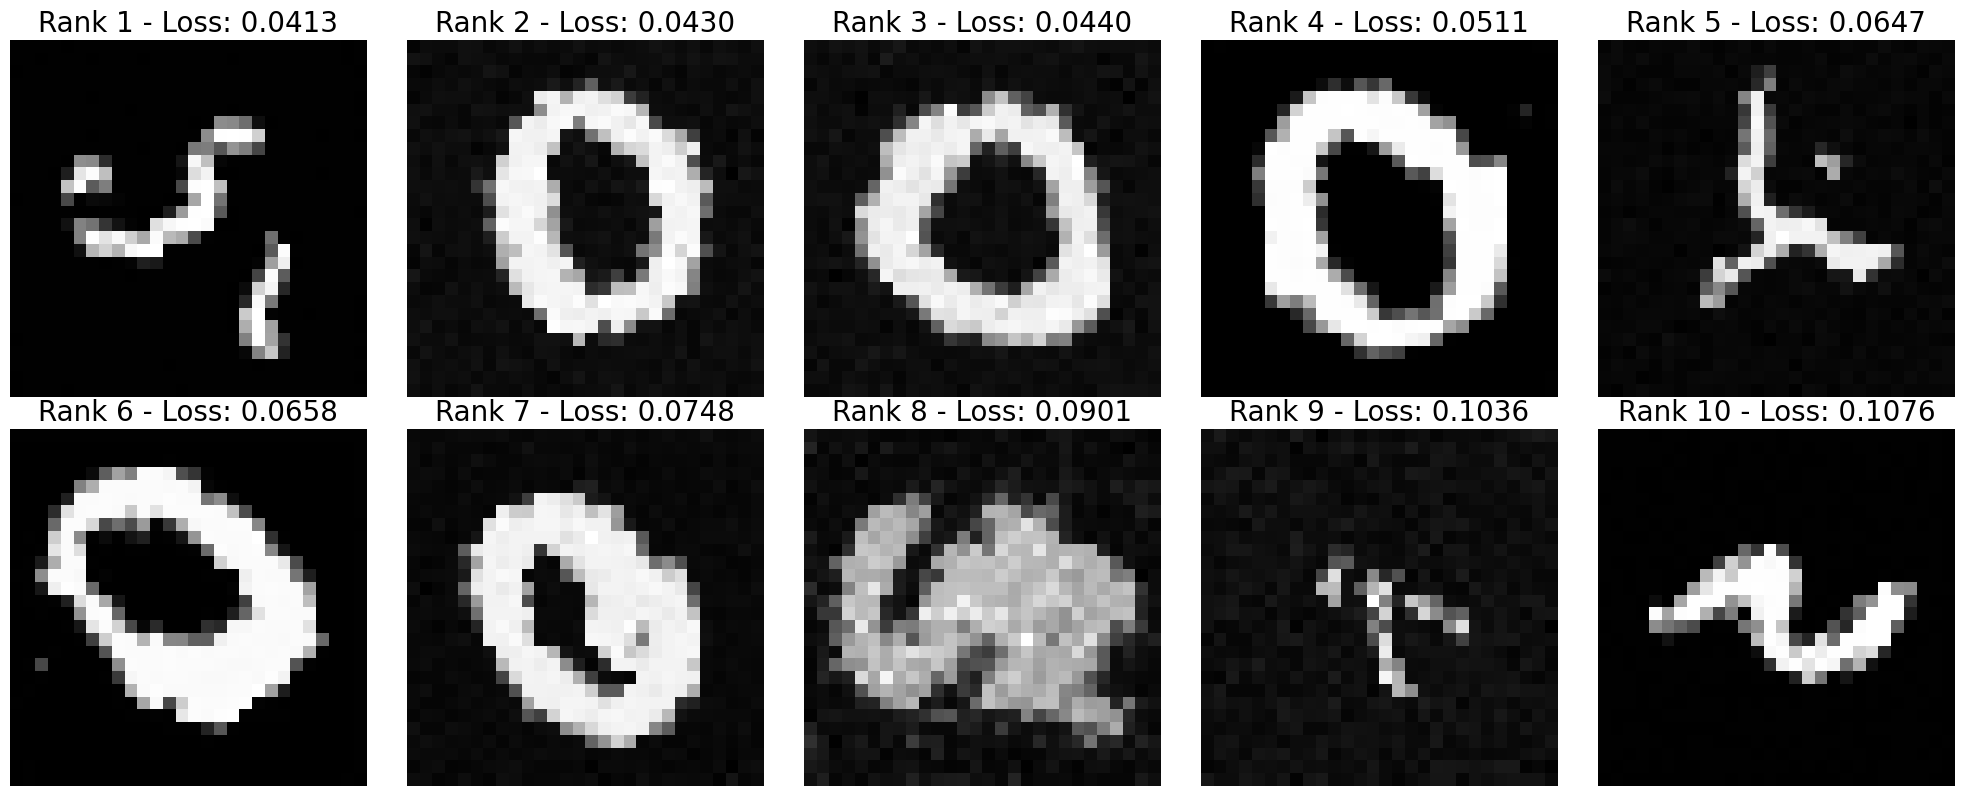

## bi-modal

In [ ]:

# checkpoint_path = "/content/circular_ict_epoch_600.pt"#/content/circular_ict_epoch_30.pt"


# Define your MoG parameters
mog_means = [
    torch.tensor([180], dtype=torch.float64),
    torch.tensor([360], dtype=torch.float64),
]

mog_variances = [
    torch.tensor([[260]], dtype=torch.float64)
] * len(mog_means)

weights = torch.tensor([1 / len(mog_means)] * len(mog_means), dtype=torch.float64)

# Run experiments with both image and distribution plotting
results = run_optimization_experiment(
    mog_means=mog_means,
    mog_variances=mog_variances,
    weights=weights,
    n_runs=25,
    seed=1,
    device="cuda",
    plot_after_each=True,      # Plot individual result after each optimization
    plot_top_k=10,              # Show top 10 grid after each optimization
    plot_distributions=True,    # Also plot angle distributions
    sample_nsamples=500,         # Number of samples for distribution plots
    num_x_t=10
)

##unimodal

In [ ]:

# checkpoint_path = "/content/circular_ict_epoch_600.pt"#/content/circular_ict_epoch_30.pt"


# Define your MoG parameters
mog_means = [
    # torch.tensor([180], dtype=torch.float64),
    torch.tensor([360], dtype=torch.float64),
]

mog_variances = [
    torch.tensor([[620]], dtype=torch.float64)
] * len(mog_means)

weights = torch.tensor([1 / len(mog_means)] * len(mog_means), dtype=torch.float64)

# Run experiments with both image and distribution plotting
results = run_optimization_experiment(
    mog_means=mog_means,
    mog_variances=mog_variances,
    weights=weights,
    n_runs=25,
    seed=1,
    device="cuda",
    plot_after_each=True,      # Plot individual result after each optimization
    plot_top_k=10,              # Show top 10 grid after each optimization
    plot_distributions=True,    # Also plot angle distributions
    sample_nsamples=500,         # Number of samples for distribution plots
    num_x_t=10
)